# Reconstrução 3D com COLMAP: Structure from Motion

**Objectivos de aprendizagem:**
- Compreender a arquitetura geral de um pipeline SfM (feature extraction → matching → sparse reconstruction → refinement)
- Executar COLMAP de forma prática com dados próprios
- Interpretar e diagnosticar falhas de reconstrução (overlap insuficiente, textura pobre, drift)
- Visualizar poses da câmara e nuvens de pontos 3D
- Avaliar qualidade através de análise de erro de reprojeção e comprimento de pistas

**Competência C5.5:** O estudante é capaz de executar um pipeline Structure from Motion completo utilizando COLMAP: extração de features, correspondência, SfM esparso, inspecção da nuvem de pontos e poses da câmara, diagnóstico de falhas.

**Contexto:** Esta é a segunda semana do Módulo 5 (Modelos 3D Clássicos). Baseia-se na calibração de câmara de NB5.1 e prepara o caminho para refinamento denso (NB5.6).

---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/ComputerVision/blob/main/NB5.5_colmap_sfm.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

In [ ]:
### !!! Executar esta célula primeiro, se dentro do Colab
# Clona o repositório completo para garantir acesso aos dados/imagens.

from pathlib import Path
import os

repo_dir = Path("/content/ComputerVision")

if not repo_dir.exists():
    !git clone https://github.com/ppestana-supervisor/ComputerVision.git {repo_dir}

os.chdir(repo_dir)
print("Diretório atual:", os.getcwd())
print("Conteúdo:", os.listdir("."))

In [ ]:
# important installs - not on Colab default
!apt-get update -qq
!apt-get install -y -qq colmap
!pip install -q open3d

In [5]:
import os
import shutil
import sqlite3
import struct
import subprocess
#subprocess.run(["colmap", "-h"])
import warnings
from pathlib import Path
import cv2

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Dependência opcional para visualização de nuvens de pontos
try:
    import open3d as o3d
    HAS_OPEN3D = True
except ImportError:
    HAS_OPEN3D = False
    o3d = None

# Verificar se COLMAP está disponível no PATH
COLMAP_BIN = shutil.which("colmap")
HAS_COLMAP = COLMAP_BIN is not None

print("Verificação do ambiente:")
print(f"  COLMAP disponível: {'sim' if HAS_COLMAP else 'não'}")
print(f"  Open3D disponível: {'sim' if HAS_OPEN3D else 'não'}")

if not HAS_COLMAP:
    print("\nNota: COLMAP não foi encontrado no PATH.")
    print("As células que chamam COLMAP por linha de comando não irão correr até o COLMAP estar instalado/acessível.")

if not HAS_OPEN3D:
    print("\nNota: open3d não está instalado.")
    print("As nuvens PLY poderão ser guardadas, mas não visualizadas interativamente dentro do notebook.")

Verificação do ambiente:
  COLMAP disponível: sim
  Open3D disponível: sim


## Fase 1: COLMAP: Instalação e Ambiente

COLMAP é uma ferramenta de reconstrução 3D de código aberto, baseada em C++, que implementa algoritmos de ponta para Structure from Motion.

**Componentes principais:**
- **Feature Extractor:** Detecta e descreve features (geralmente SIFT) em cada imagem
- **Matcher:** Estabelece correspondências entre imagens (exhaustive, sequential, etc.)
- **Mapper (SfM):** Reconstrói incrementalmente a geometria (poses + nuvem 3D)
- **Database:** Armazena features, matches e metadados em SQLite

Neste notebook, seguiremos o pipeline clássico: feature_extractor → exhaustive_matcher → mapper.

In [ ]:
from pathlib import Path
import shutil
import urllib.request
import zipfile

# Detectar se estamos no Colab
IN_COLAB = "google.colab" in str(get_ipython())

# Pasta base temporária:
# - Colab: /content
# - local: pasta atual do notebook
ROOT = Path("/content") if IN_COLAB else Path.cwd()

# Dataset oficial COLMAP
DATA_ROOT = ROOT / "colmap_data"
project_dir = DATA_ROOT / "south-building"

zip_path = DATA_ROOT / "south-building.zip"
dataset_url = "https://github.com/colmap/colmap/releases/download/3.11.1/south-building.zip"

# Descarregar e extrair dataset se ainda não existir
if not project_dir.exists():
    DATA_ROOT.mkdir(parents=True, exist_ok=True)

    print("A descarregar o dataset South Building...")
    urllib.request.urlretrieve(dataset_url, zip_path)

    print("A extrair o dataset...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_ROOT)

# Estrutura COLMAP
images_dir = project_dir / "images"
sparse_dir = project_dir / "sparse"
dense_dir = project_dir / "dense"
database_path = project_dir / "database.db"

# Só limpar outputs, nunca apagar images
RESET_OUTPUTS = True

if RESET_OUTPUTS:
    if database_path.exists():
        database_path.unlink()

    if sparse_dir.exists():
        shutil.rmtree(sparse_dir)

    if dense_dir.exists():
        shutil.rmtree(dense_dir)

sparse_dir.mkdir(parents=True, exist_ok=True)
dense_dir.mkdir(parents=True, exist_ok=True)

print("Projeto COLMAP preparado:")
print(f"  Projeto:   {project_dir}")
print(f"  Imagens:   {images_dir}")
print(f"  Sparse:    {sparse_dir}")
print(f"  Dense:     {dense_dir}")
print(f"  Database:  {database_path}")
print(f"  Nº imagens: {len(list(images_dir.glob('*')))}")

Projeto COLMAP preparado:
  Imagens:   south-building/images
  Sparse:    south-building/sparse
  Dense:     south-building/dense
  Database:  south-building/database.db


## Fase 2: Dados de Entrada: Critérios para um Bom Dataset SfM

A qualidade de uma reconstrução SfM depende criticamente da qualidade do dataset de imagens:

**Sobreposição (Overlap):**
- Imagens consecutivas devem sobrepor-se por 30–70%
- Pares com sobreposição insuficiente não podem ser posicionados com confiança
- Falha típica: "0 images registered" → causa raiz é falta de overlap detectável

**Textura:**
- Regiões sem textura (paredes brancas, céu) causam features vazias
- Bom SfM requer textura discriminativa em múltiplas escalas

**Iluminação:**
- Iluminação consistente através de todas as imagens é ideal
- Mudanças drásticas de iluminação (dia/noite) invalidam matches

**Movimento da câmara:**
- Câmara deve mover-se em torno do objecto (não manter distância constante)
- Rotações + translações = melhor triangulação

Antes de executar COLMAP, vamos fazer uma **verificação de sobreposição pré-voo** para diagnosticar problemas no dataset.

In [7]:
source_images_dir = images_dir
max_images = 20

extensions = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}

image_paths = sorted([
    p for p in source_images_dir.iterdir()
    if p.is_file() and p.suffix in extensions
])

image_paths = image_paths[:max_images]

print(f"Pasta de imagens: {source_images_dir.resolve()}")
print(f"Imagens encontradas: {len(image_paths)}")

if len(image_paths) < 2:
    raise RuntimeError(
        "São necessárias pelo menos 2 imagens para Structure from Motion."
    )

for p in image_paths:
    print(f"  - {p.name}")

Pasta de imagens: /Users/pedropestana/Dropbox/Aberta/Classes/Visão por Computador (22305)/Re-estruturação Computer Vision/Computer Vision Building Claude/notebooks/south-building/images
Imagens encontradas: 20
  - P1180141.JPG
  - P1180142.JPG
  - P1180143.JPG
  - P1180144.JPG
  - P1180145.JPG
  - P1180146.JPG
  - P1180147.JPG
  - P1180148.JPG
  - P1180149.JPG
  - P1180150.JPG
  - P1180151.JPG
  - P1180152.JPG
  - P1180153.JPG
  - P1180154.JPG
  - P1180155.JPG
  - P1180156.JPG
  - P1180157.JPG
  - P1180158.JPG
  - P1180159.JPG
  - P1180160.JPG


Diagnóstico preliminar:
  Imagens selecionadas: 20
  Este notebook usará o próprio COLMAP para extração SIFT, matching e reconstrução.
  Testes rápidos com ORB podem subestimar a sobreposição real e não serão usados como critério de exclusão.


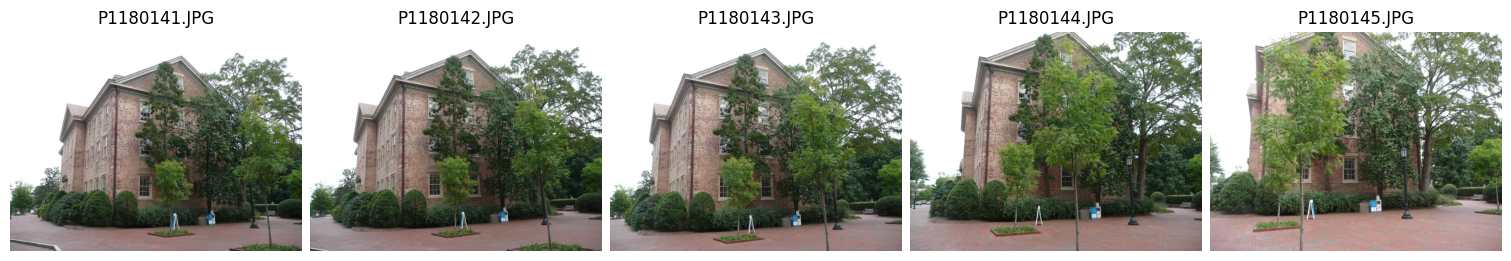

In [8]:
print("Diagnóstico preliminar:")
print(f"  Imagens selecionadas: {len(image_paths)}")
print("  Este notebook usará o próprio COLMAP para extração SIFT, matching e reconstrução.")
print("  Testes rápidos com ORB podem subestimar a sobreposição real e não serão usados como critério de exclusão.")

fig, axes = plt.subplots(1, min(5, len(image_paths)), figsize=(15, 4), constrained_layout=True)

if len(image_paths) == 1:
    axes = [axes]

for ax, img_path in zip(axes, image_paths[:5]):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img_rgb)
    ax.set_title(img_path.name)
    ax.axis("off")

plt.show()

## Fase 3: Extração de Features com COLMAP

O componente `feature_extractor` de COLMAP:
- Detecta keypoints SIFT em cada imagem (escala invariante)
- Computa descritores de 128-dimensões para cada keypoint
- Armazena features num banco de dados SQLite junto com metadados de câmara

**SIFT (Scale Invariant Feature Transform):**
- Robusto a rotação, escala, mudanças de iluminação
- Gold-standard em SfM há décadas (apesar da ascensão de deep learning)
- Cada imagem típica: 1000–10000 features (depende de resolução, textura)

**Parâmetros COLMAP:**
- `--ImageReader.camera_model`: Modelo de câmara (SIMPLE_RADIAL para câmaras calibradas, OPENCV para distorção complexa)
- `--SiftExtraction.max_image_size`: Redimensionar se imagens forem muito grandes (padrão 3200 px)

In [21]:
db_path = database_path

if db_path.exists():
    db_path.unlink()

cmd = [
    "colmap", "feature_extractor",
    "--database_path", str(db_path),
    "--image_path", str(images_dir),
    "--ImageReader.camera_model", "SIMPLE_RADIAL"
]

print(f'Executando:\n{" ".join(cmd)}\n')

result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    timeout=300
)

if result.returncode != 0:
    print("STDOUT:")
    print(result.stdout)
    print("\nSTDERR:")
    print(result.stderr)
    raise RuntimeError("A extração de features falhou.")

print("Extração de features concluída.")

conn = sqlite3.connect(str(db_path))
cursor = conn.cursor()

print("\nTabelas:")
cursor.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name
""")

for (table_name,) in cursor.fetchall():
    cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
    count = cursor.fetchone()[0]
    print(f"  {table_name}: {count}")

print("\nKeypoints por imagem:")
cursor.execute("""
    SELECT images.name, keypoints.rows
    FROM images
    LEFT JOIN keypoints
    ON images.image_id = keypoints.image_id
    ORDER BY images.image_id
""")

for name, rows in cursor.fetchall():
    rows = 0 if rows is None else rows
    print(f"  {name}: {rows}")

conn.close()

Executando:
colmap feature_extractor --database_path south-building/database.db --image_path south-building/images --ImageReader.camera_model SIMPLE_RADIAL

Extração de features concluída.

Tabelas:
  cameras: 1
  descriptors: 128
  frame_data: 128
  frames: 128
  images: 128
  keypoints: 128
  matches: 0
  pose_priors: 128
  rig_sensors: 0
  rigs: 1
  sqlite_sequence: 4
  two_view_geometries: 0

Keypoints por imagem:
  P1180141.JPG: 12728
  P1180142.JPG: 8519
  P1180143.JPG: 8838
  P1180144.JPG: 9539
  P1180145.JPG: 10331
  P1180146.JPG: 11787
  P1180147.JPG: 11881
  P1180148.JPG: 11217
  P1180149.JPG: 10463
  P1180150.JPG: 10906
  P1180151.JPG: 11093
  P1180152.JPG: 11321
  P1180153.JPG: 10888
  P1180154.JPG: 12425
  P1180155.JPG: 8253
  P1180156.JPG: 11465
  P1180157.JPG: 11249
  P1180158.JPG: 11522
  P1180159.JPG: 12949
  P1180160.JPG: 12007
  P1180161.JPG: 12066
  P1180162.JPG: 11527
  P1180163.JPG: 10570
  P1180164.JPG: 11922
  P1180165.JPG: 11701
  P1180166.JPG: 8430
  P1180167.

## Fase 4: Correspondência de Features: Exhaustive Matching

O componente `exhaustive_matcher` compara features entre **todos os pares de imagens**:
- Para cada keypoint na imagem i, encontra o vizinho mais próximo em imagem j usando descritores
- Aplica verificação geométrica (geometria epipolar): apenas matches que respeitam a constraints são guardados
- Uma correspondência "geometricamente verificada" implica que os dois keypoints podem ter vindo do mesmo ponto 3D

**Estratégias de matching:**
- **Exhaustive:** Compara todos os pares (O(n²)) — apropriado para < 500 imagens
- **Sequential:** Apenas pares adjacentes (mais rápido para sequências video)
- **Spatial:** Agrupa imagens por proximidade GPS (para datasets grandes)

Usaremos sequential matching aqui para rapidez... se estiver com GPU pode experimentar Exhaustive.

In [10]:
cmd = [
    "colmap", "sequential_matcher",
    "--database_path", str(db_path),
    "--SequentialMatching.overlap", "10"
]

print("Executando:")
print(" ".join(cmd))
print()

process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

try:
    for line in process.stdout:
        print(line, end="")

    return_code = process.wait()

    if return_code != 0:
        raise RuntimeError(f"O matching falhou com código {return_code}.")

    print("\n Matching sequencial concluído.")

except KeyboardInterrupt:
    process.terminate()
    raise RuntimeError("Matching interrompido pelo utilizador.")

Executando:
colmap sequential_matcher --database_path south-building/database.db --SequentialMatching.overlap 10

I20260515 16:58:03.365008 0x16dd97000 feature_matching.cc:195] === Feature matching & geometric verification ===
I20260515 16:58:03.414301 0x16de23000 sift.cc:1559] Creating SIFT GPU feature matcher
I20260515 16:58:03.452598 0x16dd97000 pairing.cc:415] Generating sequential image pairs...
I20260515 16:58:03.452971 0x16dd97000 pairing.cc:473] Processing image [1/128]
I20260515 16:58:03.931609 0x16dd97000 feature_matching.cc:217] in 0.479s
I20260515 16:58:03.931643 0x16dd97000 pairing.cc:473] Processing image [2/128]
I20260515 16:58:04.374358 0x16dd97000 feature_matching.cc:217] in 0.443s
I20260515 16:58:04.374382 0x16dd97000 pairing.cc:473] Processing image [3/128]
I20260515 16:58:04.732925 0x16dd97000 feature_matching.cc:217] in 0.359s
I20260515 16:58:04.732953 0x16dd97000 pairing.cc:473] Processing image [4/128]
I20260515 16:58:05.203353 0x16dd97000 feature_matching.cc:217

In [11]:
conn = sqlite3.connect(str(db_path))
cursor = conn.cursor()

cursor.execute("SELECT COUNT(*) FROM matches")
num_pairs_with_matches = cursor.fetchone()[0]

cursor.execute("SELECT SUM(rows) FROM matches")
total_raw_matches = cursor.fetchone()[0] or 0

cursor.execute("SELECT COUNT(*) FROM two_view_geometries")
num_verified_pairs = cursor.fetchone()[0]

cursor.execute("SELECT SUM(rows) FROM two_view_geometries")
total_verified_matches = cursor.fetchone()[0] or 0

print("Resumo do matching:")
print(f"  Pares com matches brutos:          {num_pairs_with_matches}")
print(f"  Matches brutos totais:             {total_raw_matches}")
print(f"  Pares geometricamente verificados: {num_verified_pairs}")
print(f"  Matches verificados totais:        {total_verified_matches}")

print("\nTop 10 pares por matches verificados:")

cursor.execute("""
    SELECT pair_id, rows
    FROM two_view_geometries
    WHERE rows > 0
    ORDER BY rows DESC
    LIMIT 10
""")

for pair_id, n_matches in cursor.fetchall():
    image_id1 = pair_id // 2147483647
    image_id2 = pair_id % 2147483647
    print(f"  imagens {image_id1} ↔ {image_id2}: {n_matches} matches verificados")

conn.close()

Resumo do matching:
  Pares com matches brutos:          769
  Matches brutos totais:             642555
  Pares geometricamente verificados: 769
  Matches verificados totais:        619567

Top 10 pares por matches verificados:
  imagens 37 ↔ 38: 6250 matches verificados
  imagens 70 ↔ 71: 5620 matches verificados
  imagens 67 ↔ 68: 5528 matches verificados
  imagens 68 ↔ 69: 5476 matches verificados
  imagens 71 ↔ 72: 5384 matches verificados
  imagens 69 ↔ 70: 5372 matches verificados
  imagens 36 ↔ 37: 4758 matches verificados
  imagens 27 ↔ 28: 4724 matches verificados
  imagens 78 ↔ 79: 4540 matches verificados
  imagens 46 ↔ 47: 4230 matches verificados


## Fase 5: Reconstrução Sparse 3D: Incremental SfM

O componente `mapper` reconstrói incrementalmente a estrutura 3D:

1. **Seleção de seed pair:** Escolhe o par com mais matches geometricamente verificados
2. **Triangulação inicial:** Os pontos 3D são criados a partir do par seed utilizando triangulação linear
3. **Registo incremental:** Cada imagem restante é posicionada (P3P + RANSAC) utilizando matches com os pontos 3D existentes
4. **Triangulação e refinamento:** Novos pontos 3D são criados, bundle adjustment refina poses e poses

**Bundle Adjustment:**
- Otimização não-linear de todas as poses e pontos 3D em simultâneo
- Minimiza erro de reprojeção (distância entre pixel detectado e pixel projetado)
- Executado periodicamente para manter precisão

**Diagnóstico:**
- Se nenhuma imagem for registada ("0 images registered") → overlap insuficiente, features vazias, ou drift severo
- Se algumas imagens não forem registadas → isoladas do grafo de correspondências

In [12]:
cmd = [
    "colmap", "mapper",
    "--database_path", str(db_path),
    "--image_path", str(images_dir),
    "--output_path", str(sparse_dir)
]

print("Executando:")
print(" ".join(cmd))
print()

process = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

try:
    for line in process.stdout:
        print(line, end="")

    return_code = process.wait()

    if return_code != 0:
        raise RuntimeError(f"O mapper terminou com código {return_code}.")

    print("\n Reconstrução SfM esparsa concluída.")

except KeyboardInterrupt:
    process.terminate()
    raise RuntimeError("Mapper interrompido pelo utilizador.")

models = sorted([p for p in sparse_dir.iterdir() if p.is_dir()])

if not models:
    raise RuntimeError("Nenhum modelo esparso foi produzido pelo COLMAP.")

model_dir = models[0]

print(f"\nModelo principal encontrado em: {model_dir}")

for filename in ["cameras.bin", "images.bin", "points3D.bin"]:
    path = model_dir / filename
    print(f"  {filename}: {'✓' if path.exists() else '✗'}")

Executando:
colmap mapper --database_path south-building/database.db --image_path south-building/images --output_path south-building/sparse

I20260515 16:59:10.518297 0x1fe032240 incremental_pipeline.cc:265] Loading database
I20260515 16:59:10.518996 0x1fe032240 database_cache.cc:72] Loading rigs...
I20260515 16:59:10.519020 0x1fe032240 database_cache.cc:82]  1 in 0.000s
I20260515 16:59:10.519030 0x1fe032240 database_cache.cc:90] Loading cameras...
I20260515 16:59:10.519038 0x1fe032240 database_cache.cc:108]  1 in 0.000s
I20260515 16:59:10.519041 0x1fe032240 database_cache.cc:116] Loading frames...
I20260515 16:59:10.519117 0x1fe032240 database_cache.cc:126]  128 in 0.000s
I20260515 16:59:10.519121 0x1fe032240 database_cache.cc:134] Loading matches...
I20260515 16:59:10.522002 0x1fe032240 database_cache.cc:139]  494 in 0.003s
I20260515 16:59:10.522013 0x1fe032240 database_cache.cc:147] Loading images...
I20260515 16:59:10.542151 0x1fe032240 database_cache.cc:241]  128 in 0.020s (connec

## Fase 6: Carregamento do Modelo COLMAP: Formato Binário

COLMAP armazena o resultado SfM num formato binário compacto:
- **cameras.bin:** Parâmetros de câmara (matriz K, distorção)
- **images.bin:** Poses (R, t) e keypoints detectados para cada imagem
- **points3D.bin:** Coordenadas XYZ, cor RGB, e pistas de visibilidade para cada ponto 3D

Implementaremos um leitor Python puro (struct) para desserializar estes ficheiros.

In [22]:
models = sorted([p for p in sparse_dir.iterdir() if p.is_dir()])
if not models:
    raise RuntimeError("Nenhum modelo esparso encontrado.")

model_dir = models[0]
model_txt_dir = model_dir / "txt"
model_txt_dir.mkdir(exist_ok=True)

cmd = [
    "colmap", "model_converter",
    "--input_path", str(model_dir),
    "--output_path", str(model_txt_dir),
    "--output_type", "TXT"
]

print("Executando:")
print(" ".join(cmd))

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Falha ao converter modelo COLMAP para TXT.")

print("Modelo convertido para TXT.")
print(f"Diretório: {model_txt_dir}")

Executando:
colmap model_converter --input_path south-building/sparse/0 --output_path south-building/sparse/0/txt --output_type TXT
Modelo convertido para TXT.
Diretório: south-building/sparse/0/txt


In [23]:
cameras_txt = model_txt_dir / "cameras.txt"
images_txt = model_txt_dir / "images.txt"
points3d_txt = model_txt_dir / "points3D.txt"

def count_data_lines(path):
    with open(path, "r") as f:
        return sum(1 for line in f if line.strip() and not line.startswith("#"))

num_cameras = count_data_lines(cameras_txt)

num_registered_images = count_data_lines(images_txt) // 2

num_points3d = count_data_lines(points3d_txt)

errors = []
track_lengths = []

with open(points3d_txt, "r") as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue

        parts = line.split()
        errors.append(float(parts[7]))
        track_lengths.append((len(parts) - 8) // 2)

errors = np.array(errors)
track_lengths = np.array(track_lengths)

registered_names = set()

with open(images_txt, "r") as f:
    lines = [
        line.strip()
        for line in f
        if line.strip() and not line.startswith("#")
    ]

for i in range(0, len(lines), 2):
    parts = lines[i].split()
    registered_names.add(parts[-1])

all_image_names = {
    p.name for p in images_dir.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
}

unregistered = sorted(all_image_names - registered_names)

print("Resumo do modelo COLMAP:")
print(f"  Câmaras:              {num_cameras}")
print(f"  Imagens registadas:   {num_registered_images} / {len(all_image_names)}")
print(f"  Imagens não registadas: {len(unregistered)}")
print(f"  Pontos 3D:            {num_points3d}")

if num_points3d > 0:
    print("\nQualidade geométrica:")
    print(f"  Erro reprojeção médio: {errors.mean():.3f} px")
    print(f"  Erro reprojeção mediano: {np.median(errors):.3f} px")
    print(f"  Erro reprojeção 95%: {np.percentile(errors, 95):.3f} px")
    print(f"  Comprimento médio das tracks: {track_lengths.mean():.2f} imagens")

if unregistered:
    print("\nImagens não registadas:")
    for name in unregistered[:20]:
        print(f"  - {name}")
    if len(unregistered) > 20:
        print(f"  ... mais {len(unregistered)-20}")
        

Resumo do modelo COLMAP:
  Câmaras:              1
  Imagens registadas:   128 / 128
  Imagens não registadas: 0
  Pontos 3D:            70743

Qualidade geométrica:
  Erro reprojeção médio: 0.543 px
  Erro reprojeção mediano: 0.437 px
  Erro reprojeção 95%: 1.381 px
  Comprimento médio das tracks: 5.53 imagens


## Fase 7: Visualização de Poses: Câmaras no Espaço 3D

Uma pose de câmara é representada por uma matriz de rotação **R** (3×3) e um vetor de translação **t** (3×1).
- A câmara está no espaço mundial em posição **-R.T @ t** (centro da câmara)
- O eixo z da câmara aponta na direção **-R[2, :]** (convenção OpenCV)

Vamos visualizar os centros das câmaras e as suas direções de visão num gráfico 3D.

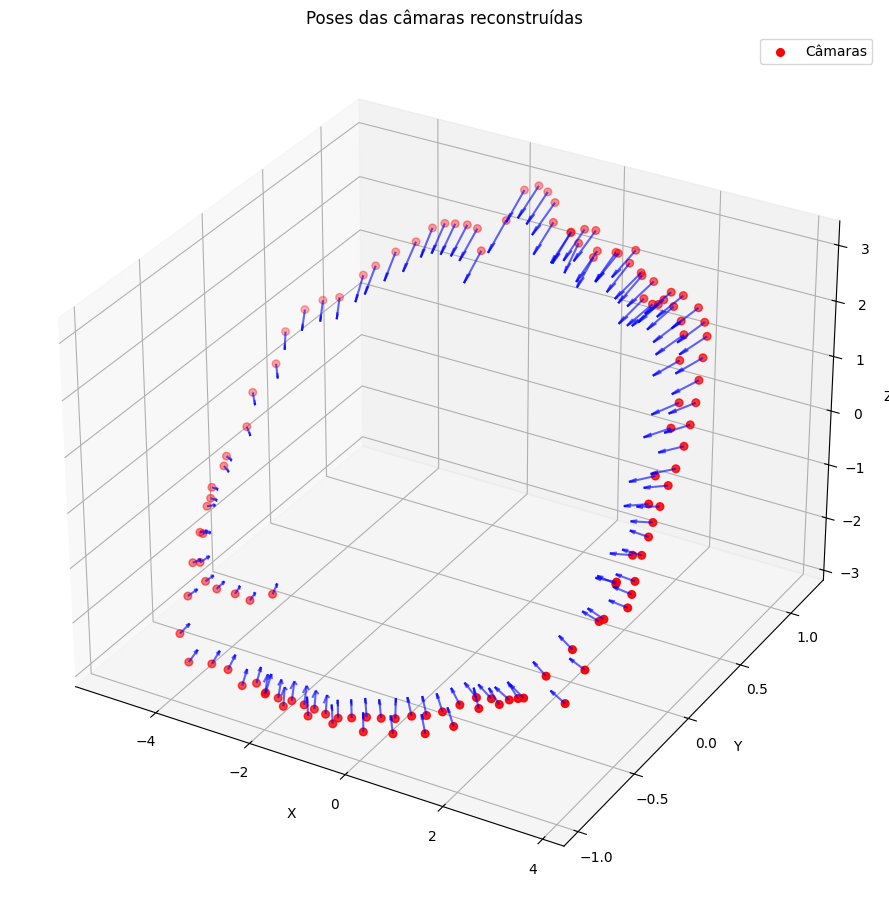

Visualização das poses:
  Número de câmaras: 128
  Vermelho: centros das câmaras
  Azul: direções de observação


In [15]:
def quaternion_to_rotation_matrix(qvec):
    qw, qx, qy, qz = qvec

    return np.array([
        [1 - 2*(qy**2 + qz**2),     2*(qx*qy - qz*qw),     2*(qx*qz + qy*qw)],
        [    2*(qx*qy + qz*qw), 1 - 2*(qx**2 + qz**2),     2*(qy*qz - qx*qw)],
        [    2*(qx*qz - qy*qw),     2*(qy*qz + qx*qw), 1 - 2*(qx**2 + qy**2)]
    ])


camera_centers = []
viewing_dirs = []

with open(images_txt, "r") as f:
    lines = [
        line.strip()
        for line in f
        if line.strip() and not line.startswith("#")
    ]

for i in range(0, len(lines), 2):
    parts = lines[i].split()

    qvec = np.array([float(v) for v in parts[1:5]])
    tvec = np.array([float(v) for v in parts[5:8]])

    R = quaternion_to_rotation_matrix(qvec)

    center = -R.T @ tvec
    viewing_dir = R.T[:, 2]

    camera_centers.append(center)
    viewing_dirs.append(viewing_dir)

camera_centers = np.array(camera_centers)
viewing_dirs = np.array(viewing_dirs)

fig = plt.figure(figsize=(12, 9), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    camera_centers[:, 0],
    camera_centers[:, 1],
    camera_centers[:, 2],
    c="red",
    s=30,
    label="Câmaras"
)

scene_extent = np.linalg.norm(
    camera_centers.max(axis=0) - camera_centers.min(axis=0)
)

arrow_scale = scene_extent * 0.03

ax.quiver(
    camera_centers[:, 0],
    camera_centers[:, 1],
    camera_centers[:, 2],
    viewing_dirs[:, 0],
    viewing_dirs[:, 1],
    viewing_dirs[:, 2],
    length=arrow_scale,
    normalize=True,
    color="blue",
    alpha=0.6
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Poses das câmaras reconstruídas")
ax.legend()

plt.show()

print("Visualização das poses:")
print(f"  Número de câmaras: {len(camera_centers)}")
print("  Vermelho: centros das câmaras")
print("  Azul: direções de observação")

## Fase 8: Inspeção da Nuvem de Pontos 3D

A nuvem de pontos é a reconstrução geométrica final:
- Cada ponto tem uma coordenada XYZ e cor RGB (média dos pixels detectados)
- Esparsidade: apenas pontos triangulados de features correspondidas
- Qualidade reflete overlap, textura, e estabilidade do SfM

Para visualização interactiva em alta resolução, exportamos como PLY. Se open3d estiver disponível, carregamos interactivamente.

Subamostragem: 60083 → 40000 pontos.


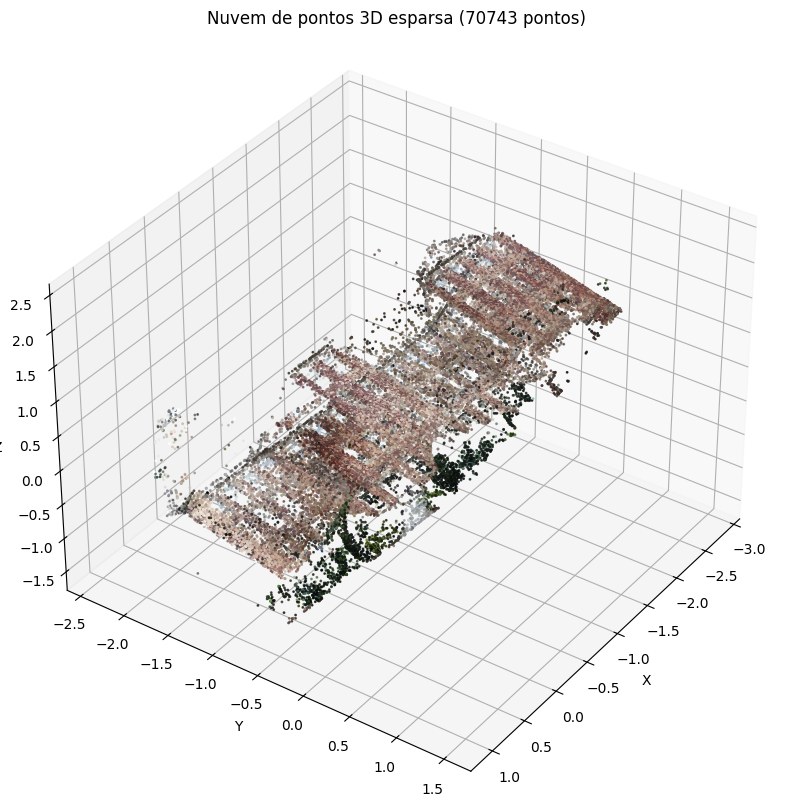

Resumo da nuvem de pontos:
  Pontos totais: 70743
  Após filtro de erro: 67206
  Após recorte espacial: 60083
  Erro máximo visualizado: 1.381 px


In [24]:
points3d_txt = model_txt_dir / "points3D.txt"

xyz_list = []
rgb_list = []
errors = []

with open(points3d_txt, "r") as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue

        parts = line.split()

        x, y, z = map(float, parts[1:4])
        r, g, b = map(int, parts[4:7])
        error = float(parts[7])

        xyz_list.append([x, y, z])
        rgb_list.append([r, g, b])
        errors.append(error)

xyz = np.array(xyz_list, dtype=np.float32)
rgb = np.array(rgb_list, dtype=np.uint8)
errors = np.array(errors, dtype=np.float32)

if len(xyz) == 0:
    raise RuntimeError("Nenhum ponto 3D disponível. O SfM pode ter falhado.")

# Filtrar alguns outliers para visualização
error_threshold = np.percentile(errors, 95)
visual_mask = errors <= error_threshold

xyz_vis = xyz[visual_mask]
rgb_vis = rgb[visual_mask]

lower = np.percentile(xyz_vis, 2, axis=0)
upper = np.percentile(xyz_vis, 98, axis=0)

spatial_mask = np.all(
    (xyz_vis >= lower) & (xyz_vis <= upper),
    axis=1
)

xyz_clean = xyz_vis[spatial_mask]
rgb_clean = rgb_vis[spatial_mask]

max_points = 40000

if len(xyz_clean) > max_points:
    rng = np.random.default_rng(42)
    indices = rng.choice(len(xyz_clean), size=max_points, replace=False)
    xyz_plot = xyz_clean[indices]
    rgb_plot = rgb_clean[indices]

    print(f"Subamostragem: {len(xyz_clean)} → {len(xyz_plot)} pontos.")
else:
    xyz_plot = xyz_clean
    rgb_plot = rgb_clean

fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    xyz_plot[:, 0],
    xyz_plot[:, 1],
    xyz_plot[:, 2],
    c=rgb_plot / 255.0,
    s=1,
    alpha=0.8
)

# escala geométrica equilibrada
center = xyz_plot.mean(axis=0)
radius = np.max(np.ptp(xyz_plot, axis=0)) / 2

ax.set_xlim(center[0] - radius, center[0] + radius)
ax.set_ylim(center[1] - radius, center[1] + radius)
ax.set_zlim(center[2] - radius, center[2] + radius)

ax.view_init(elev=35, azim=35)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"Nuvem de pontos 3D esparsa ({len(xyz)} pontos)")

plt.show()

print("Resumo da nuvem de pontos:")
print(f"  Pontos totais: {len(xyz)}")
print(f"  Após filtro de erro: {len(xyz_vis)}")
print(f"  Após recorte espacial: {len(xyz_clean)}")
print(f"  Erro máximo visualizado: {error_threshold:.3f} px")

In [17]:
ply_path = project_dir / "points3d_sparse.ply"

if HAS_OPEN3D:
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(xyz)
    pcd.colors = o3d.utility.Vector3dVector(rgb.astype(np.float32) / 255.0)

    o3d.io.write_point_cloud(str(ply_path), pcd)
    print(f"✓ PLY guardado com Open3D: {ply_path}")
    print(f"  Pontos: {len(pcd.points)}")

else:
    with open(ply_path, "w") as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(xyz)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write("end_header\n")

        for p, c in zip(xyz, rgb):
            f.write(
                f"{p[0]:.6f} {p[1]:.6f} {p[2]:.6f} "
                f"{c[0]} {c[1]} {c[2]}\n"
            )

    print(f" PLY guardado: {ply_path}")

✓ PLY guardado com Open3D: south-building/points3d_sparse.ply
  Pontos: 70743


## Fase 9: Análise de Erro de Reprojeção

O **erro de reprojeção** mede a qualidade de um ponto 3D:
- Para cada imagem em que o ponto é visível, projetamos a sua coordenada 3D utilizando a câmara
- Comparamos a projeção com a posição do keypoint detectado no pixel
- Erro = distância euclidiana (em pixels)

**Interpretação:**
- Erro < 0.5 px: Excelente (SfM estável, poses precisas)
- Erro 0.5–1.0 px: Bom (normal para SfM)
- Erro 1.0–2.0 px: Aceitável (mas observar)
- Erro > 2.0 px: Outlier (possível erro de correspondência, distorção)

Imagens com erro médio elevado são suspeitas de má calibração ou pose incorreta.

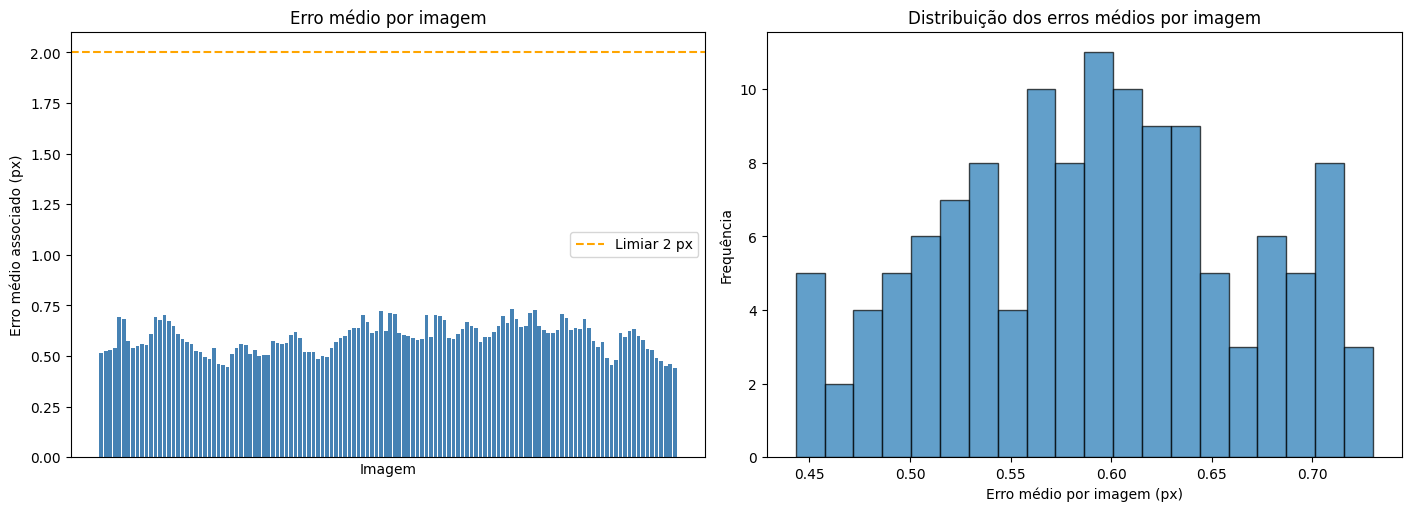

Erro médio por imagem:
  Mín: 0.443 px
  Méd: 0.591 px
  Máx: 0.730 px

 Nenhuma imagem apresenta erro médio acima de 2.0 px.


In [25]:
point_errors = {}

with open(points3d_txt, "r") as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue

        parts = line.split()
        point3d_id = int(parts[0])
        error = float(parts[7])
        point_errors[point3d_id] = error

image_error_values = {}

with open(images_txt, "r") as f:
    lines = [
        line.strip()
        for line in f
        if line.strip() and not line.startswith("#")
    ]

for i in range(0, len(lines), 2):
    header = lines[i].split()
    image_name = header[-1]

    obs_line = lines[i + 1].split()

    point_ids = [int(obs_line[j]) for j in range(2, len(obs_line), 3)]

    errors_for_image = [
        point_errors[pid]
        for pid in point_ids
        if pid != -1 and pid in point_errors
    ]

    if errors_for_image:
        image_error_values[image_name] = np.mean(errors_for_image)

if not image_error_values:
    raise RuntimeError("Não foi possível calcular erros por imagem.")

names = list(image_error_values.keys())
errors_img = np.array(list(image_error_values.values()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

colors = ["red" if e > 2.0 else "steelblue" for e in errors_img]

ax1.bar(range(len(errors_img)), errors_img, color=colors)
ax1.set_xlabel("Imagem")
ax1.set_ylabel("Erro médio associado (px)")
ax1.set_title("Erro médio por imagem")
ax1.axhline(y=2.0, color="orange", linestyle="--", label="Limiar 2 px")
ax1.legend()
ax1.set_xticks([])

ax2.hist(errors_img, bins=20, edgecolor="black", alpha=0.7)
ax2.set_xlabel("Erro médio por imagem (px)")
ax2.set_ylabel("Frequência")
ax2.set_title("Distribuição dos erros médios por imagem")

plt.show()

print("Erro médio por imagem:")
print(f"  Mín: {np.min(errors_img):.3f} px")
print(f"  Méd: {np.mean(errors_img):.3f} px")
print(f"  Máx: {np.max(errors_img):.3f} px")

outliers = [
    (name, err)
    for name, err in image_error_values.items()
    if err > 2.0
]

if outliers:
    print(f"\n {len(outliers)} imagem(ns) com erro médio > 2.0 px:")
    for name, err in outliers:
        print(f"   {name}: {err:.3f} px")
else:
    print("\n Nenhuma imagem apresenta erro médio acima de 2.0 px.")

## Fase 10: Análise de Comprimento de Pista

A **pista (track)** de um ponto 3D é o conjunto de imagens em que ele é visível.
- **Comprimento de pista** = número de imagens
- Pontos com pista curta (1–2 imagens): pouco estáveis, potencialmente outliers
- Pontos com pista longa (5+ imagens): bem triangulados, geometricamente coerentes

Uma boa reconstrução SfM espera comprimento médio >= 3.

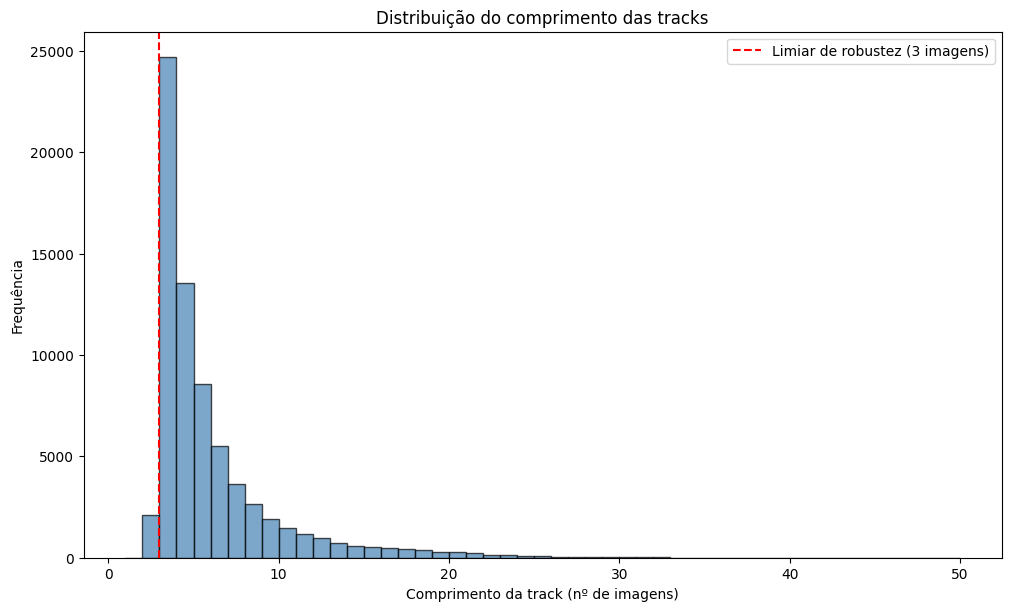

Estatísticas das tracks:
  Mínimo: 2
  Média: 5.53
  Mediana: 4.00
  Máximo: 49
  % com track ≥ 3 imagens: 97.0%
  % com track ≥ 5 imagens: 43.0%


In [19]:
track_lengths = []

with open(points3d_txt, "r") as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue

        parts = line.split()

        # após os primeiros 8 campos começa TRACK[]
        track_data = parts[8:]

        track_length = len(track_data) // 2
        track_lengths.append(track_length)

track_lengths = np.array(track_lengths)

if len(track_lengths) == 0:
    raise RuntimeError("Nenhuma track encontrada.")

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

bins = range(1, np.max(track_lengths) + 2)

ax.hist(
    track_lengths,
    bins=bins,
    edgecolor="black",
    alpha=0.7,
    color="steelblue"
)

ax.set_xlabel("Comprimento da track (nº de imagens)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição do comprimento das tracks")

ax.axvline(
    x=3,
    color="red",
    linestyle="--",
    label="Limiar de robustez (3 imagens)"
)

ax.legend()

plt.show()

pct_ge_3 = 100.0 * np.sum(track_lengths >= 3) / len(track_lengths)
pct_ge_5 = 100.0 * np.sum(track_lengths >= 5) / len(track_lengths)

print("Estatísticas das tracks:")
print(f"  Mínimo: {np.min(track_lengths)}")
print(f"  Média: {np.mean(track_lengths):.2f}")
print(f"  Mediana: {np.median(track_lengths):.2f}")
print(f"  Máximo: {np.max(track_lengths)}")
print(f"  % com track ≥ 3 imagens: {pct_ge_3:.1f}%")
print(f"  % com track ≥ 5 imagens: {pct_ge_5:.1f}%")

## Fase 11: Diagnóstico de Falhas: Imagens Não Registadas

Se nem todas as imagens foram registadas pelo SfM:
1. Identificar quais falharam
2. Para cada falha: detetar features, comparar com registadas, e diagnosticar causa
3. Causas típicas:
   - **Isolamento:** Nenhum match com imagens registadas (overlap insuficiente)
   - **Textura:** Poucos features detectados (região sem textura)
   - **Ambiguidade:** Matches mas posição incerta (múltiplas soluções P3P)

In [20]:
registered_names = set()

with open(images_txt, "r") as f:
    lines = [
        line.strip()
        for line in f
        if line.strip() and not line.startswith("#")
    ]

for i in range(0, len(lines), 2):
    parts = lines[i].split()
    registered_names.add(parts[-1])

all_image_paths = sorted([
    p for p in images_dir.iterdir()
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
])

unregistered = [
    p for p in all_image_paths
    if p.name not in registered_names
]

print("Diagnóstico de registo de imagens:")
print(f"  Imagens disponíveis:     {len(all_image_paths)}")
print(f"  Imagens registadas:      {len(registered_names)}")
print(f"  Imagens não registadas:  {len(unregistered)}")

if not unregistered:
    print("\n Todas as imagens foram registadas com sucesso.")
else:
    print("\nImagens não registadas:")
    for p in unregistered:
        print(f"  - {p.name}")

    print("\nPossíveis causas:")
    print("  - Pouca sobreposição com imagens vizinhas")
    print("  - Falta de textura ou imagem desfocada")
    print("  - Forte variação de iluminação")
    print("  - Movimento demasiado grande entre vistas")
    print("  - Imagem duplicada, muito semelhante ou com geometria ambígua")

Diagnóstico de registo de imagens:
  Imagens disponíveis:     128
  Imagens registadas:      128
  Imagens não registadas:  0

✓ Todas as imagens foram registadas com sucesso.


## Reflexão e Análise Crítica

A execução de um pipeline SfM prático revela os desafios reais da reconstrução 3D:

**Questões de reflexão:**

1. **Sucesso da reconstrução:**
   - Quantas imagens foram registadas com sucesso?
   - Se alguma falhou, qual foi a causa mais provável (overlap insuficiente, features escassas, textura pobre, ou isolamento)?

2. **Qualidade da nuvem de pontos:**
   - A nuvem de pontos cobre bem o objecto de interesse?
   - Onde é mais esparsa e porquê? (regiões sem textura, oclusão, superfícies refletivas)

3. **Erro de reprojeção:**
   - Qual é o erro de reprojeção médio?
   - O que significaria um erro > 5 píxeis? (má pose, correspondência errada, ou distorção não modelada)

4. **Melhorias práticas:**
   - Se quisesse melhorar a reconstrução, qual seria a **primeira** mudança?
     - Capturar mais imagens com melhor overlap?
     - Melhorar iluminação?
     - Maior overlap (mover câmara mais lentamente)?
     - Usar calibração mais precisa?

5. **Comparação com alternativas:**
   - SfM incrementalista vs. RANSAC global: qual é mais robusto? Porquê?
   - Como afetaria o uso de features deep learning (SIFT vs. SuperPoint) a robustez?